# Paper ELMECS - Análisis del Dataset de Entrenamiento (v2)

Lee el archivo local `data/contextualized_hate_speech_train.csv` y realiza un análisis exploratorio del split de entrenamiento.

**Columnas principales:**  
`text` — comentario, `context_tweet` — título de la noticia, `HATEFUL` — etiqueta binaria de odio  
Categorías de odio: `CALLS`, `WOMEN`, `LGBTI`, `RACISM`, `CLASS`, `POLITICS`, `DISABLED`, `APPEARANCE`, `CRIMINAL`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1. Carga del dataset

In [2]:
df = pd.read_csv('data/contextualized_hate_speech_train.csv', parse_dates=['date_tweet'])
print(f'Shape: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
df.head(3)

Shape: (36857, 18)
Columnas: ['id', 'title', 'text', 'context_tweet', 'HATEFUL', 'body', 'CALLS', 'WOMEN', 'LGBTI', 'RACISM', 'CLASS', 'POLITICS', 'DISABLED', 'APPEARANCE', 'CRIMINAL', 'title_norm', 'medio', 'date_tweet']


,id,title,text,context_tweet,HATEFUL,body,CALLS,WOMEN,LGBTI,RACISM,CLASS,POLITICS,DISABLED,APPEARANCE,CRIMINAL,title_norm,medio,date_tweet
0,343726,Video: salió de la cárcel por el coronavirus y...,@usuario Uno menos,Video: salió de la cárcel por el coronavirus y...,1,"Un hombre de 46 años, que cumplía una condena ...",0,0,0,0,0,0,0,0,1,Video: salió de la cárcel por el coronavirus y...,clarincom,2020-04-22 20:59:00.600
1,384799,La muerte de Solange: su padre no pudo darle e...,@usuario #QueSeVayanTodos @usuario @usuario @u...,La carta que escribió Solange antes de morir: ...,0,"Solange Musse, la hija del hombre que había vi...",0,0,0,0,0,0,0,0,0,La muerte de Solange: su padre no pudo darle e...,infobae,2020-08-21 21:41:03.300
2,399435,Alberto Fernández negocia la compra de 15 mill...,"@usuario Te falta negociar con Cuba, mamerto.",Alberto Fernández negocia la compra de 15 mill...,0,Alberto Fernández desplegó una estrategia de a...,0,0,0,0,0,0,0,0,0,Alberto Fernández negocia la compra de 15 mill...,infobae,2020-12-18 09:23:04.800


In [3]:
df.dtypes

id                        int64
title                       str
text                        str
context_tweet               str
HATEFUL                   int64
body                        str
CALLS                     int64
WOMEN                     int64
LGBTI                     int64
RACISM                    int64
CLASS                     int64
POLITICS                  int64
DISABLED                  int64
APPEARANCE                int64
CRIMINAL                  int64
title_norm                  str
medio                       str
date_tweet       datetime64[us]
dtype: object

In [4]:
print('Valores nulos por columna:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Valores nulos por columna:
medio         237
date_tweet    237
dtype: int64


## 2. Distribución de la etiqueta `HATEFUL`

In [5]:
vc = df['HATEFUL'].value_counts().rename({0: 'No odio', 1: 'Odio'})
print(vc)
print(f'\nProporción de odio: {vc["Odio"] / len(df):.1%}')

HATEFUL
No odio    31284
Odio        5573
Name: count, dtype: int64

Proporción de odio: 15.1%


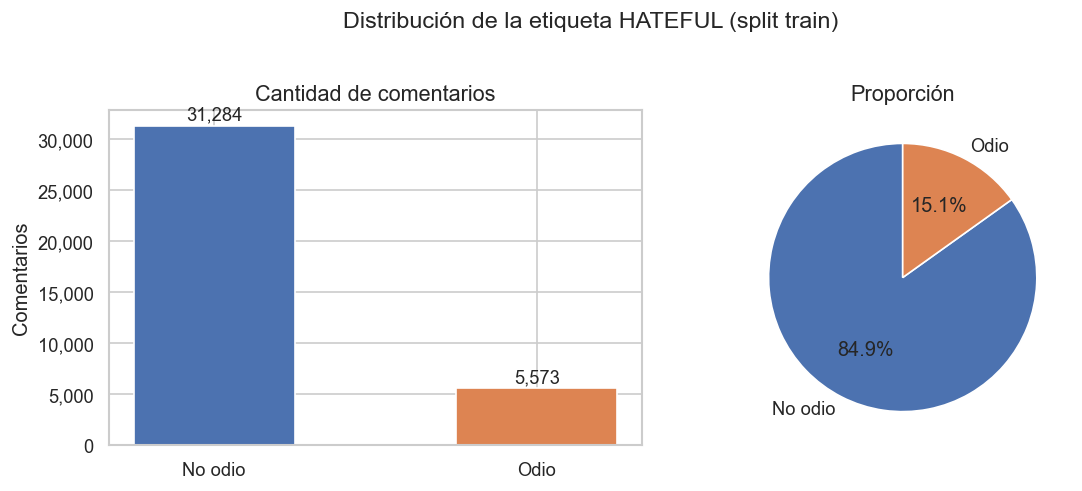

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Barplot
ax = axes[0]
colors = ['#4C72B0', '#DD8452']
bars = ax.bar(vc.index, vc.values, color=colors, edgecolor='white', width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{bar.get_height():,}', ha='center', va='bottom', fontsize=11)
ax.set_title('Cantidad de comentarios', fontsize=13)
ax.set_ylabel('Comentarios')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie
ax2 = axes[1]
ax2.pie(vc.values, labels=vc.index, autopct='%1.1f%%',
        colors=colors, startangle=90, wedgeprops=dict(edgecolor='white'))
ax2.set_title('Proporción', fontsize=13)

plt.suptitle('Distribución de la etiqueta HATEFUL (split train)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Distribución de categorías de odio

Las categorías solo son relevantes en los comentarios con `HATEFUL=1`.

In [7]:
LABEL_COLS = ['CALLS', 'WOMEN', 'LGBTI', 'RACISM', 'CLASS', 'POLITICS', 'DISABLED', 'APPEARANCE', 'CRIMINAL']

LABEL_NAMES = {
    'CALLS':      'Llamados a la acción',
    'WOMEN':      'Mujeres',
    'LGBTI':      'LGBTI',
    'RACISM':     'Racismo / xenofobia',
    'CLASS':      'Clase social',
    'POLITICS':   'Política',
    'DISABLED':   'Discapacidad',
    'APPEARANCE': 'Apariencia física',
    'CRIMINAL':   'Criminal / delincuente',
}

In [8]:
# Sobre el total del dataset
cat_counts_all = df[LABEL_COLS].sum().rename(LABEL_NAMES).sort_values(ascending=False)

# Sobre el subconjunto HATEFUL=1
df_hate = df[df['HATEFUL'] == 1].copy()
cat_counts_hate = df_hate[LABEL_COLS].sum().rename(LABEL_NAMES).sort_values(ascending=False)

print('Frecuencia de categorías (total dataset):')
print(cat_counts_all.to_string())
print()
print('Frecuencia de categorías (solo HATEFUL=1):')
print(cat_counts_hate.to_string())

Frecuencia de categorías (total dataset):
Racismo / xenofobia       1566
Apariencia física         1166
Criminal / delincuente    1030
Política                   922
Llamados a la acción       916
Mujeres                    844
Clase social               544
LGBTI                      491
Discapacidad               390

Frecuencia de categorías (solo HATEFUL=1):
Racismo / xenofobia       1566
Apariencia física         1166
Criminal / delincuente    1030
Política                   922
Llamados a la acción       916
Mujeres                    844
Clase social               544
LGBTI                      491
Discapacidad               390


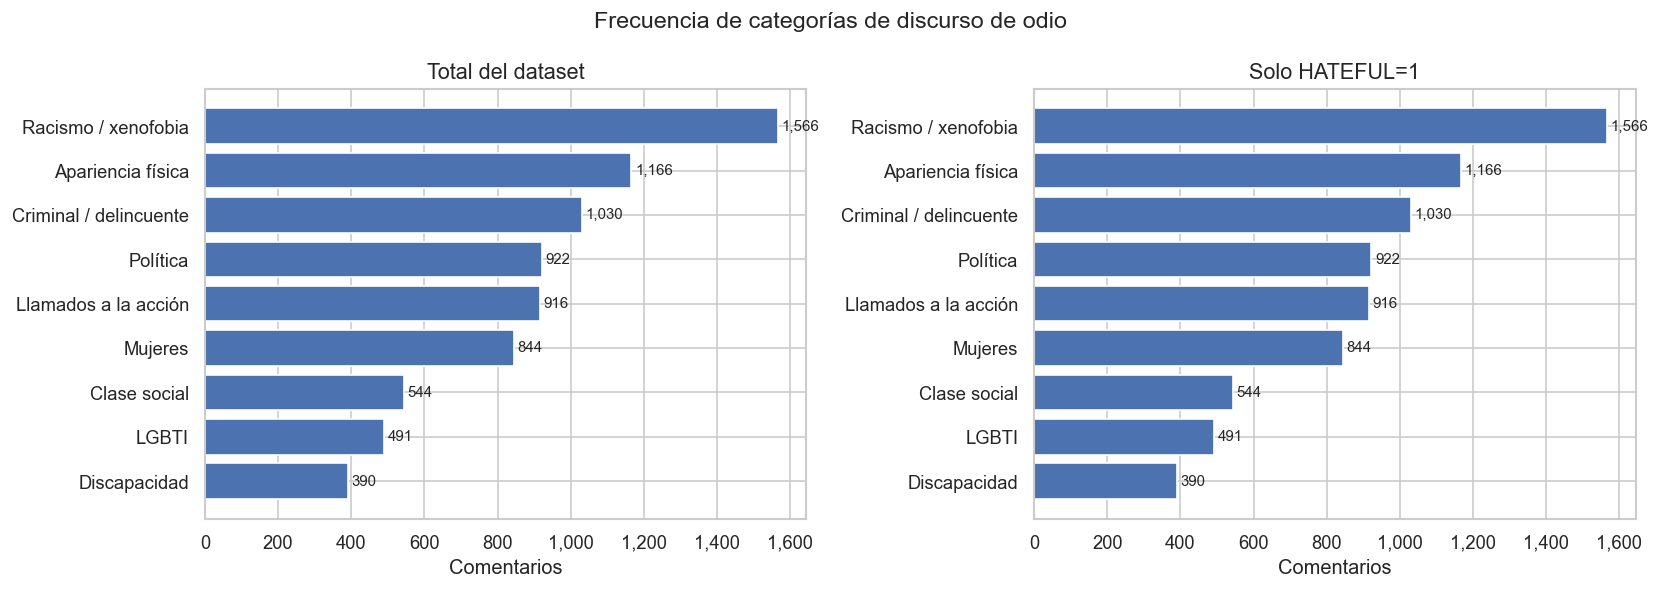

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counts, title in zip(axes,
                              [cat_counts_all, cat_counts_hate],
                              ['Total del dataset', 'Solo HATEFUL=1']):
    bars = ax.barh(counts.index[::-1], counts.values[::-1], color='#4C72B0', edgecolor='white')
    for bar in bars:
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
                f'{int(bar.get_width()):,}', va='center', fontsize=9)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Comentarios')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Frecuencia de categorías de discurso de odio', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Análisis multi-etiqueta

¿Cuántas categorías tiene asignadas cada comentario odioso?

In [10]:
df_hate = df_hate.copy()
df_hate['n_labels'] = df_hate[LABEL_COLS].sum(axis=1)

print('Distribución de cantidad de etiquetas (HATEFUL=1):')
vc_labels = df_hate['n_labels'].value_counts().sort_index()
for k, v in vc_labels.items():
    print(f'  {k} etiqueta(s): {v:,} ({v/len(df_hate):.1%})')

Distribución de cantidad de etiquetas (HATEFUL=1):
  1 etiqueta(s): 3,594 (64.5%)
  2 etiqueta(s): 1,689 (30.3%)
  3 etiqueta(s): 265 (4.8%)
  4 etiqueta(s): 23 (0.4%)
  5 etiqueta(s): 2 (0.0%)


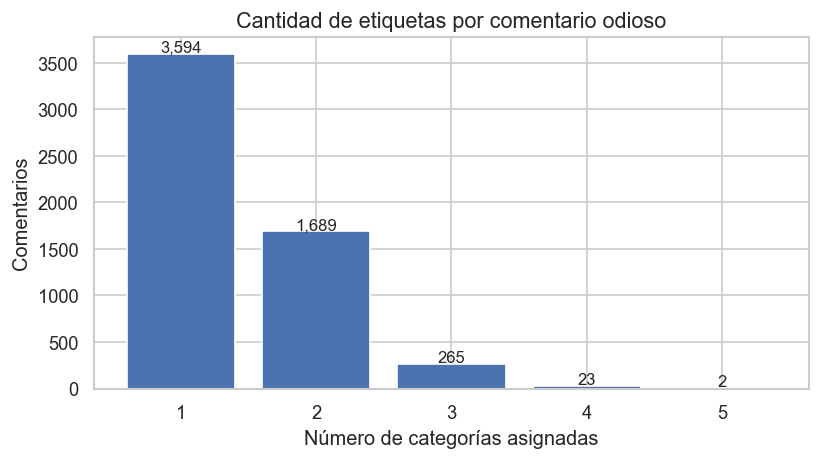

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(vc_labels.index.astype(str), vc_labels.values, color='#4C72B0', edgecolor='white')
for i, v in enumerate(vc_labels.values):
    ax.text(i, v + 20, f'{v:,}', ha='center', fontsize=10)
ax.set_xlabel('Número de categorías asignadas')
ax.set_ylabel('Comentarios')
ax.set_title('Cantidad de etiquetas por comentario odioso', fontsize=13)
plt.tight_layout()
plt.show()

### Co-ocurrencia de categorías

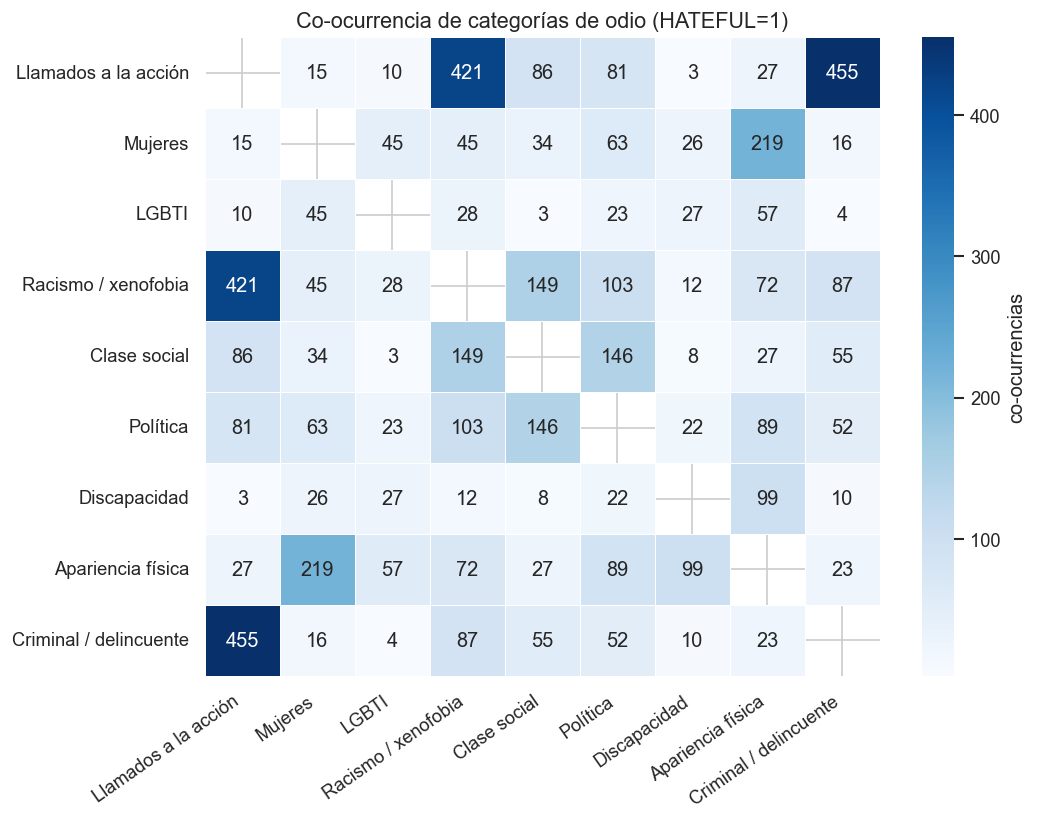

In [12]:
cooc = df_hate[LABEL_COLS].T.dot(df_hate[LABEL_COLS])
cooc.index = [LABEL_NAMES[c] for c in cooc.index]
cooc.columns = [LABEL_NAMES[c] for c in cooc.columns]

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.eye(len(cooc), dtype=bool)  # ocultar diagonal
sns.heatmap(cooc, annot=True, fmt='d', cmap='Blues', mask=mask,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'co-ocurrencias'})
ax.set_title('Co-ocurrencia de categorías de odio (HATEFUL=1)', fontsize=13)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Distribución por medio

In [13]:
medio_stats = (
    df.groupby('medio')
    .agg(
        n_comentarios=('text', 'count'),
        n_noticias=('title', 'nunique'),
        n_odio=('HATEFUL', 'sum'),
    )
    .assign(tasa_odio=lambda x: (x['n_odio'] / x['n_comentarios'] * 100).round(1),
            com_x_noticia=lambda x: (x['n_comentarios'] / x['n_noticias']).round(1))
    .sort_values('n_comentarios', ascending=False)
)
medio_stats

,n_comentarios,n_noticias,n_odio,tasa_odio,com_x_noticia
medio,,,,,
infobae,17152,469,2421,14.1,36.6
clarincom,11618,304,1957,16.8,38.2
LANACION,6406,171,885,13.8,37.5
cronica,988,33,221,22.4,29.9
perfilcom,456,13,42,9.2,35.1


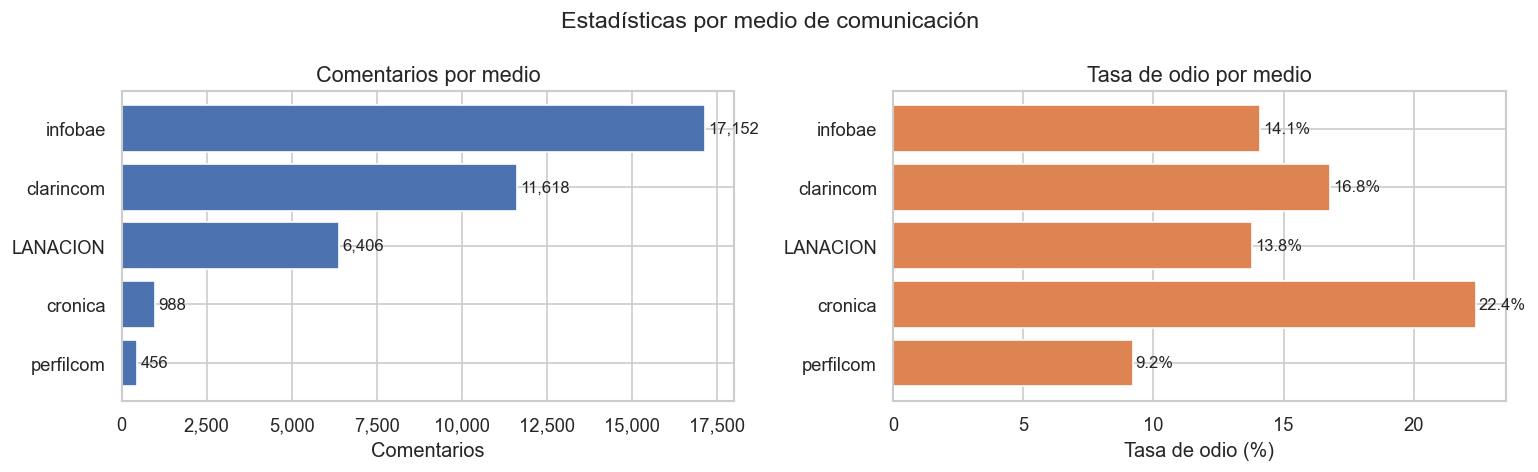

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Comentarios por medio
ax = axes[0]
ax.barh(medio_stats.index[::-1], medio_stats['n_comentarios'][::-1],
        color='#4C72B0', edgecolor='white')
for i, v in enumerate(medio_stats['n_comentarios'][::-1]):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=10)
ax.set_xlabel('Comentarios')
ax.set_title('Comentarios por medio', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Tasa de odio por medio
ax2 = axes[1]
ax2.barh(medio_stats.index[::-1], medio_stats['tasa_odio'][::-1],
         color='#DD8452', edgecolor='white')
for i, v in enumerate(medio_stats['tasa_odio'][::-1]):
    ax2.text(v + 0.1, i, f'{v}%', va='center', fontsize=10)
ax2.set_xlabel('Tasa de odio (%)')
ax2.set_title('Tasa de odio por medio', fontsize=13)

plt.suptitle('Estadísticas por medio de comunicación', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Evolución temporal

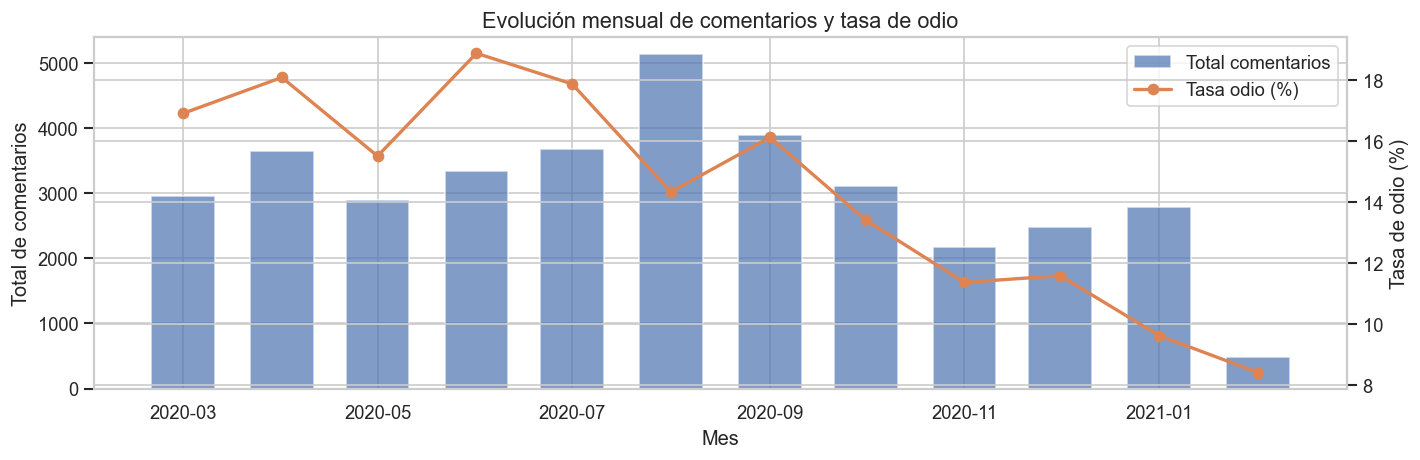

In [15]:
df_time = df.dropna(subset=['date_tweet']).copy()
df_time['mes'] = df_time['date_tweet'].dt.to_period('M')

monthly = (
    df_time.groupby('mes')
    .agg(total=('HATEFUL', 'count'), odio=('HATEFUL', 'sum'))
    .assign(tasa_odio=lambda x: x['odio'] / x['total'] * 100)
)
monthly.index = monthly.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.bar(monthly.index, monthly['total'], width=20, color='#4C72B0', alpha=0.7, label='Total comentarios')
ax2.plot(monthly.index, monthly['tasa_odio'], color='#DD8452', marker='o', linewidth=2, label='Tasa odio (%)')

ax1.set_ylabel('Total de comentarios')
ax2.set_ylabel('Tasa de odio (%)')
ax1.set_xlabel('Mes')
ax1.set_title('Evolución mensual de comentarios y tasa de odio', fontsize=13)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

## 7. Longitud de los comentarios

In [16]:
df['text_len'] = df['text'].str.len()

print('Estadísticas de longitud (caracteres):')
print(df.groupby('HATEFUL')['text_len'].describe().rename(index={0: 'No odio', 1: 'Odio'}).round(1).to_string())

Estadísticas de longitud (caracteres):
           count  mean   std   min   25%   50%    75%    max
HATEFUL                                                     
No odio  31284.0  87.2  66.0  10.0  39.0  66.0  114.0  307.0
Odio      5573.0  85.9  62.5  10.0  41.0  67.0  112.0  298.0


C:\Users\natal\AppData\Local\Temp\ipykernel_17772\343463902.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_bp, labels=['No odio', 'Odio'], patch_artist=True,


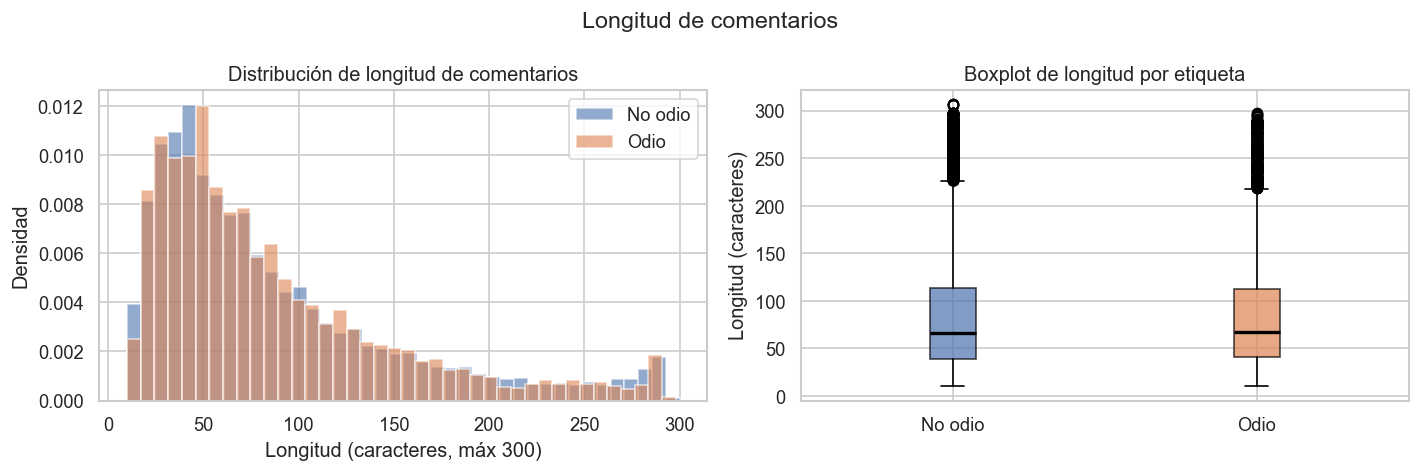

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
ax = axes[0]
for label, color, name in [(0, '#4C72B0', 'No odio'), (1, '#DD8452', 'Odio')]:
    subset = df[df['HATEFUL'] == label]['text_len']
    ax.hist(subset.clip(upper=300), bins=40, alpha=0.6, color=color, label=name, density=True)
ax.set_xlabel('Longitud (caracteres, máx 300)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de longitud de comentarios', fontsize=12)
ax.legend()

# Boxplot
ax2 = axes[1]
data_bp = [df[df['HATEFUL'] == 0]['text_len'], df[df['HATEFUL'] == 1]['text_len']]
bp = ax2.boxplot(data_bp, labels=['No odio', 'Odio'], patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#4C72B0', '#DD8452']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('Longitud (caracteres)')
ax2.set_title('Boxplot de longitud por etiqueta', fontsize=12)

plt.suptitle('Longitud de comentarios', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Resumen general

In [18]:
print('=== Resumen del dataset de entrenamiento ===')
print(f'Total de comentarios:        {len(df):>8,}')
print(f'Comentarios con odio:        {df["HATEFUL"].sum():>8,}  ({df["HATEFUL"].mean():.1%})')
print(f'Comentarios sin odio:        {(df["HATEFUL"]==0).sum():>8,}  ({(df["HATEFUL"]==0).mean():.1%})')
print(f'Noticias únicas:             {df["title"].nunique():>8,}')
print(f'Medios:                      {df["medio"].nunique():>8}')
print(f'Rango temporal:              {df["date_tweet"].min().date()} – {df["date_tweet"].max().date()}')
print(f'Longitud media comentario:   {df["text_len"].mean():>8.1f} caracteres')
print()
print('Categoría más frecuente (HATEFUL=1):', cat_counts_hate.idxmax(),
      f'({int(cat_counts_hate.max()):,} comentarios)')
print('Categoría menos frecuente:          ', cat_counts_hate.idxmin(),
      f'({int(cat_counts_hate.min()):,} comentarios)')

=== Resumen del dataset de entrenamiento ===
Total de comentarios:          36,857
Comentarios con odio:           5,573  (15.1%)
Comentarios sin odio:          31,284  (84.9%)
Noticias únicas:                  987
Medios:                             5
Rango temporal:              2020-03-01 – 2021-02-08
Longitud media comentario:       87.0 caracteres

Categoría más frecuente (HATEFUL=1): Racismo / xenofobia (1,566 comentarios)
Categoría menos frecuente:           Discapacidad (390 comentarios)
